In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Ex 1

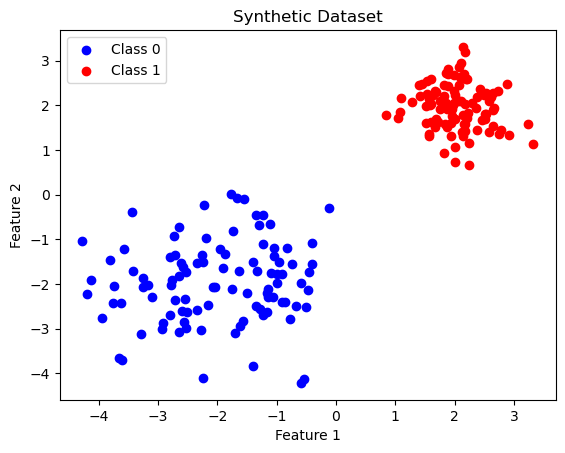

In [133]:
n_class_0_samples = 100
n_class_1_samples = 100

class_0 = np.random.normal(0, 1, size=(n_class_0_samples, 2)) + np.array([-2, -2])
class_1 = np.random.normal(0, 0.5, size=(n_class_1_samples, 2)) + np.array([2, 2])

plt.scatter(class_0[:, 0], class_0[:, 1], color='blue', label='Class 0')
plt.scatter(class_1[:, 0], class_1[:, 1], color='red', label='Class 1')
plt.title('Synthetic Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [134]:
def sigmoid(t):
    return 1 / (1 + np.exp(-t))

def l(Theta, X, Y):
    Y_hat = sigmoid(X @ Theta)
    Y_hat = np.clip(Y_hat, 1e-15, 1 - 1e-15)  # Avoid log(0)
    return - np.sum(Y * np.log(Y_hat) + (1-Y) * np.log(1 - Y_hat))

def grad_l(Theta, X, Y):
    Y_hat = sigmoid(X @ Theta)
    Y_hat = np.clip(Y_hat, 1e-15, 1 - 1e-15)  # Avoid log(0)
    return X.T @ (Y_hat - Y)

def accuracy(Theta, X, Y):
    preds = sigmoid(X @ Theta) >= 0.5
    return (preds == Y).mean()

def SGD(l, grad_l, X, Y, Theta0, lr=1e-2, batch_size=32, epochs=10):
    epoch_loss = []
    epoch_acc = []

    Theta = Theta0
    for epoch in range(epochs):
        N = len(X)
        shuffle_idx = np.random.permutation(N)

        for start in range(0, N, batch_size):
            batch_idx = shuffle_idx[start:start+batch_size]
            grad = grad_l(Theta, X[batch_idx], Y[batch_idx])
            Theta -= lr * grad

        epoch_loss.append(l(Theta, X, Y))
        epoch_acc.append(accuracy(Theta, X, Y))
            # Update the loss_val list

    return Theta, epoch, epoch_loss, epoch_acc

In [ ]:
X = np.vstack((class_0, class_1))
X = np.hstack((np.ones((X.shape[0], 1)), X))
Y = np.hstack((np.zeros(n_class_0_samples), np.ones(n_class_1_samples)))

print("First 5 samples of X:\n", X[:5])
print("\n")
print("First 5 samples of Y:\n", Y[:5])

First 5 samples of X:
 [[ 1.         -2.93360673 -3.01737451]
 [ 1.         -0.90902402 -1.77489289]
 [ 1.         -2.22606657 -0.2268493 ]
 [ 1.         -1.06344103 -2.28424808]
 [ 1.         -2.70852248 -2.35877103]]


First 5 samples of Y:
 [0. 0. 0. 0. 0.]


In [136]:
Theta0 = np.zeros(X.shape[1])
batch_size = X.shape[0]
Theta, epoch, epoch_loss, epoch_acc = SGD(l, grad_l, X, Y, Theta0=Theta0, lr=0.1, batch_size=batch_size, epochs=10)

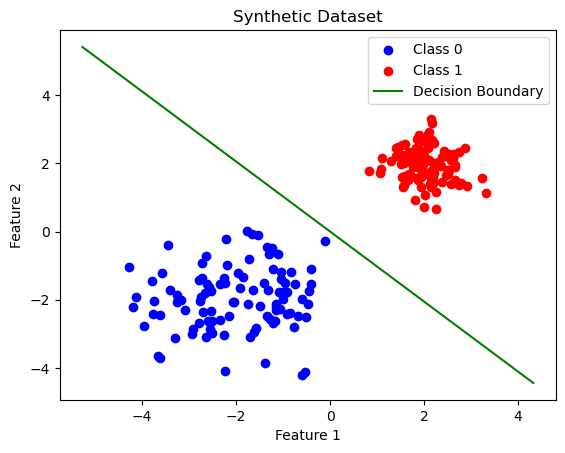

In [137]:
plt.scatter(class_0[:, 0], class_0[:, 1], color='blue', label='Class 0')
plt.scatter(class_1[:, 0], class_1[:, 1], color='red', label='Class 1')

min_max_of_feature_1 = np.array([min(X[:,1])-1, max(X[:,1])+1])
feature_2 = -(Theta[0] + Theta[1] * min_max_of_feature_1) / Theta[2]
plt.plot(min_max_of_feature_1, feature_2, label='Decision Boundary', color='green')

plt.title('Synthetic Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## Ex 2

In [138]:
batch_sizes = [1, 10, X.shape[0]]

results = pd.DataFrame([],columns=['Batch Size', 'Theta', 'Final Loss', 'Final Accuracy','Loss History', 'Accuracy History'])

for batch_size in batch_sizes:
    Theta0 = np.zeros(X.shape[1])
    Theta, epoch, epoch_loss, epoch_acc = SGD(l, grad_l, X, Y, Theta0=Theta0, lr=0.1, batch_size=batch_size, epochs=50)
    results.loc[len(results)] = [batch_size, Theta, epoch_loss[-1], epoch_acc[-1], epoch_loss, epoch_acc]
    

In [139]:
display(results.sort_values(by='Final Accuracy', ascending=False))

,Batch Size,Theta,Final Loss,Final Accuracy,Loss History,Accuracy History
0,1,"[-1.2060856388144274, 2.7653358101730174, 2.71...",0.146594,1.0,"[2.674547454002553, 1.579565604995275, 1.16748...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
1,10,"[-1.2123202097072725, 2.8028435756937045, 2.68...",0.145656,1.0,"[1.9460892709677504, 1.3204359189694252, 1.031...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
2,200,"[-0.001543458098697216, 20.209004125437072, 19...",0.000315,1.0,"[0.0003153027072223649, 0.00031529179381656493...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."


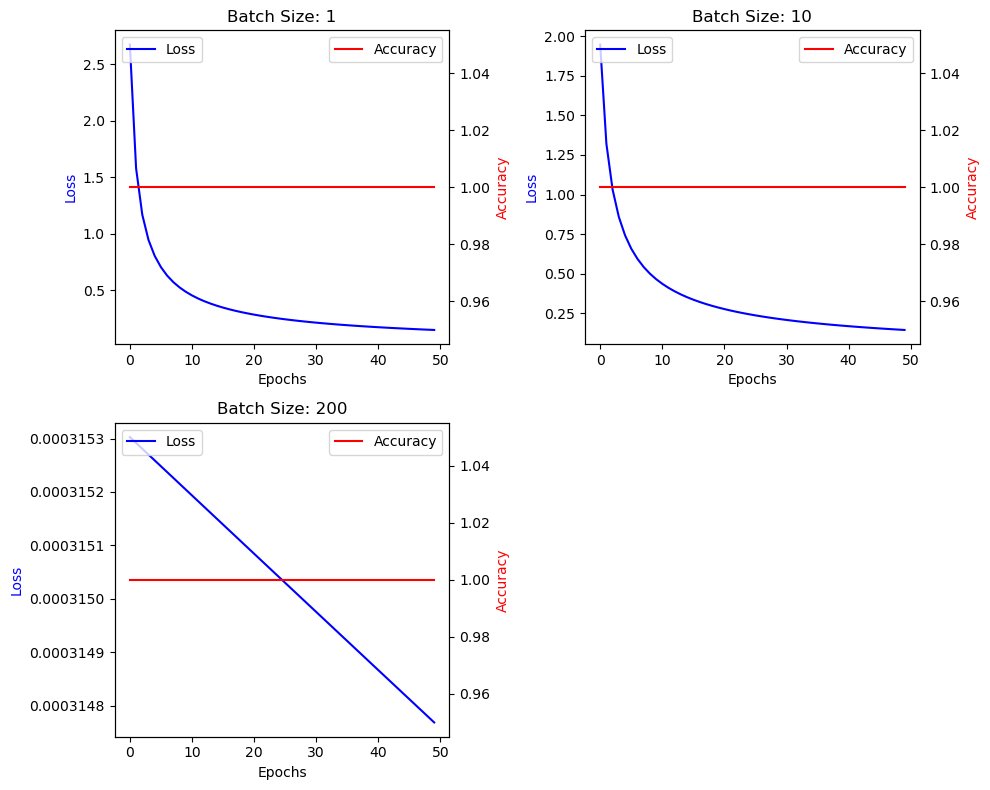

In [140]:
n_plots = len(batch_sizes)
n_cols = 2
n_rows = (n_plots + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()
for index, row in results.iterrows():
    batch_size = row['Batch Size']
    loss_history = row['Loss History']
    acc_history = row['Accuracy History']

    ax = axes[index]
    ax.plot(loss_history, label='Loss', color='blue')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss', color='blue')
    ax2 = ax.twinx()
    ax2.plot(acc_history, label='Accuracy', color='red')
    ax2.set_ylabel('Accuracy', color='red')
    ax.set_title(f'Batch Size: {batch_size}')
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

# Hide any unused subplots
for j in range(index + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

## Ex 3

In [141]:
def classification_report(Y, Y_hat):
    TP = np.sum((Y == 1) & (Y_hat == 1))
    TN = np.sum((Y == 0) & (Y_hat == 0))
    FP = np.sum((Y == 0) & (Y_hat == 1))
    FN = np.sum((Y == 1) & (Y_hat == 0))

    accuracy = (TP + TN) / len(Y)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    confusion_matrix = np.array([[TP, FP],
                                 [FN, TN]])

    report = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1_score,
        'TP': TP,
        'TN': TN,
        'FP': FP,
        'FN': FN,
        'Confusion Matrix': confusion_matrix
    }
    return report   

In [142]:
classification_reports = pd.DataFrame([], columns=['Batch Size', 'Accuracy', 'Precision', 'Recall', 'F1-Score','TP','TN','FP','FN','Confusion Matrix'])
for index, row in results.iterrows():
    batch_size = row['Batch Size']
    Theta = row['Theta']
    Y_hat = (sigmoid(X @ Theta) >= 0.5).astype(int)
    report = classification_report(Y, Y_hat)
    classification_reports.loc[len(classification_reports)] = [batch_size, report['Accuracy'], report['Precision'], report['Recall'], report['F1-Score'], report['TP'], report['TN'], report['FP'], report['FN'], report['Confusion Matrix']]

In [143]:
display(classification_reports)

,Batch Size,Accuracy,Precision,Recall,F1-Score,TP,TN,FP,FN,Confusion Matrix
0,1,1.0,1.0,1.0,1.0,100,100,0,0,"[[100, 0], [0, 100]]"
1,10,1.0,1.0,1.0,1.0,100,100,0,0,"[[100, 0], [0, 100]]"
2,200,1.0,1.0,1.0,1.0,100,100,0,0,"[[100, 0], [0, 100]]"


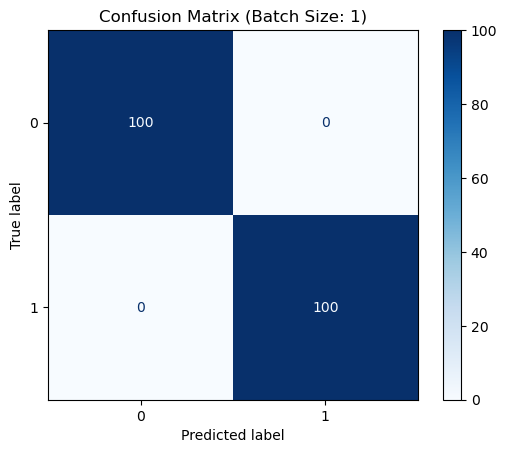

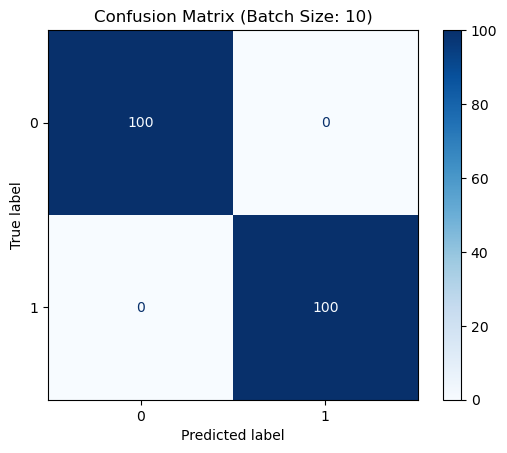

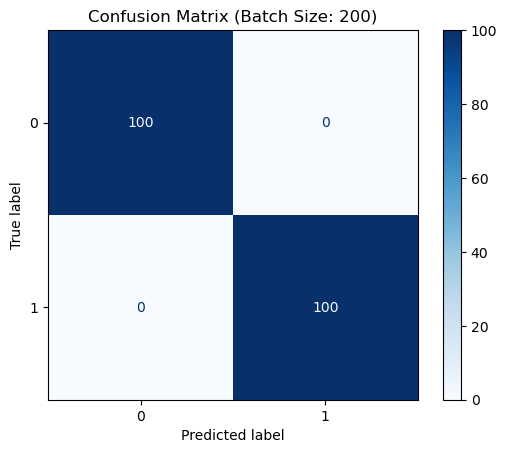

In [144]:
from sklearn.metrics import ConfusionMatrixDisplay

for index, row in classification_reports.iterrows():
    batch_size = row['Batch Size']
    cm = row['Confusion Matrix']
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix (Batch Size: {batch_size})')
    plt.show()

In [145]:
thresholds = [0.3, 0.7]
classification_reports = pd.DataFrame([], columns=['Threshold','Batch Size', 'Accuracy', 'Precision', 'Recall', 'F1-Score','TP','TN','FP','FN','Confusion Matrix'])
for threshold in thresholds:
    for index, row in results.iterrows():
        batch_size = row['Batch Size']
        Theta = row['Theta']
        Y_hat = (sigmoid(X @ Theta) >= threshold).astype(int)
        report = classification_report(Y, Y_hat)
        classification_reports.loc[len(classification_reports)] = [threshold, batch_size, report['Accuracy'], report['Precision'], report['Recall'], report['F1-Score'], report['TP'], report['TN'], report['FP'], report['FN'], report['Confusion Matrix']]

In [146]:
display(classification_reports.sort_values(by=['Accuracy']))

,Threshold,Batch Size,Accuracy,Precision,Recall,F1-Score,TP,TN,FP,FN,Confusion Matrix
0,0.3,1,1.0,1.0,1.0,1.0,100,100,0,0,"[[100, 0], [0, 100]]"
1,0.3,10,1.0,1.0,1.0,1.0,100,100,0,0,"[[100, 0], [0, 100]]"
2,0.3,200,1.0,1.0,1.0,1.0,100,100,0,0,"[[100, 0], [0, 100]]"
3,0.7,1,1.0,1.0,1.0,1.0,100,100,0,0,"[[100, 0], [0, 100]]"
4,0.7,10,1.0,1.0,1.0,1.0,100,100,0,0,"[[100, 0], [0, 100]]"
5,0.7,200,1.0,1.0,1.0,1.0,100,100,0,0,"[[100, 0], [0, 100]]"


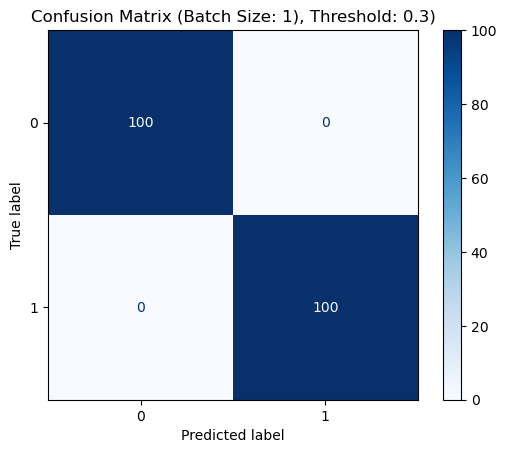

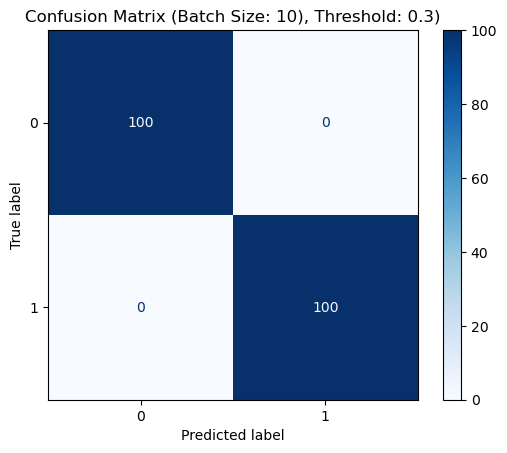

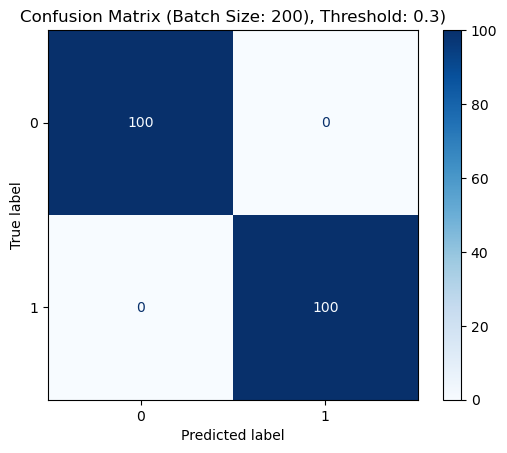

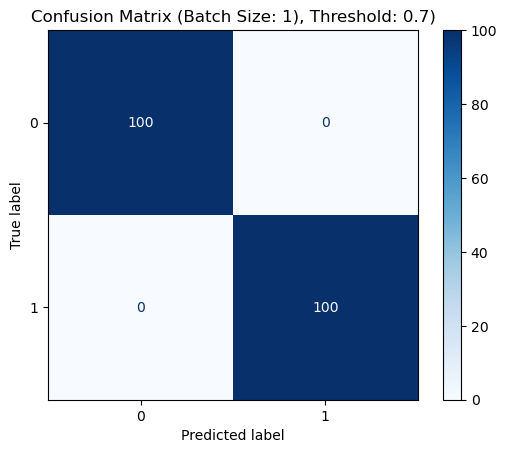

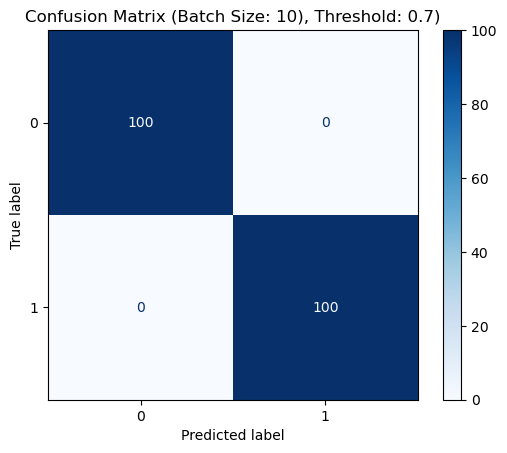

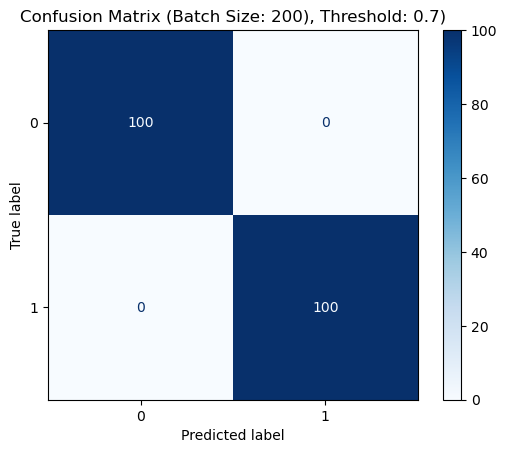

In [147]:
from sklearn.metrics import ConfusionMatrixDisplay

for index, row in classification_reports.iterrows():
    batch_size = row['Batch Size']
    cm = row['Confusion Matrix']
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix (Batch Size: {batch_size}), Threshold: {row["Threshold"]})')
    plt.show()

## Ex 4

In [148]:
df0 = pd.read_csv('./diabetes.csv')
df0.shape

(768, 9)

In [149]:
df0.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [150]:
X = df0.drop(columns=['Outcome']).values
Y = df0['Outcome'].values

X.shape, Y.shape

((768, 8), (768,))

In [151]:
X_mean, X_std = X.mean(axis=0), X.std(axis=0)
X = (X - X_mean) / X_std

X = np.hstack([np.ones((X.shape[0],1)), X])

In [155]:
def sigmoid(t):
    return 1 / (1 + np.exp(-t))

def l(Theta, X, Y):
    Y_hat = sigmoid(X @ Theta)
    return - np.sum(Y * np.log(Y_hat) + (1-Y) * np.log(1 - Y_hat))

def grad_l(Theta, X, Y):
    Y_hat = sigmoid(X @ Theta)
    return X.T @ (Y_hat - Y)

def accuracy(Theta, X, Y):
    preds = sigmoid(X @ Theta) >= 0.5
    return (preds == Y).mean()

def SGD(l, grad_l, X, Y, Theta0, lr=1e-3, batch_size=32, epochs=200):
    epoch_loss = []
    epoch_acc = []

    Theta = Theta0
    for epoch in range(epochs):
        N = len(X)
        shuffle_idx = np.random.permutation(N)

        for start in range(0, N, batch_size):
            batch_idx = shuffle_idx[start:start+batch_size]
            grad = grad_l(Theta, X[batch_idx], Y[batch_idx])
            Theta -= lr * grad

        epoch_loss.append(l(Theta, X, Y))
        epoch_acc.append(accuracy(Theta, X, Y))
            # Update the loss_val list

    return Theta, epoch, epoch_loss, epoch_acc

In [156]:
Theta0 = np.zeros(X.shape[1])
Theta, epoch, epoch_loss, epoch_acc = SGD(l, grad_l, X, Y, Theta0=Theta0)

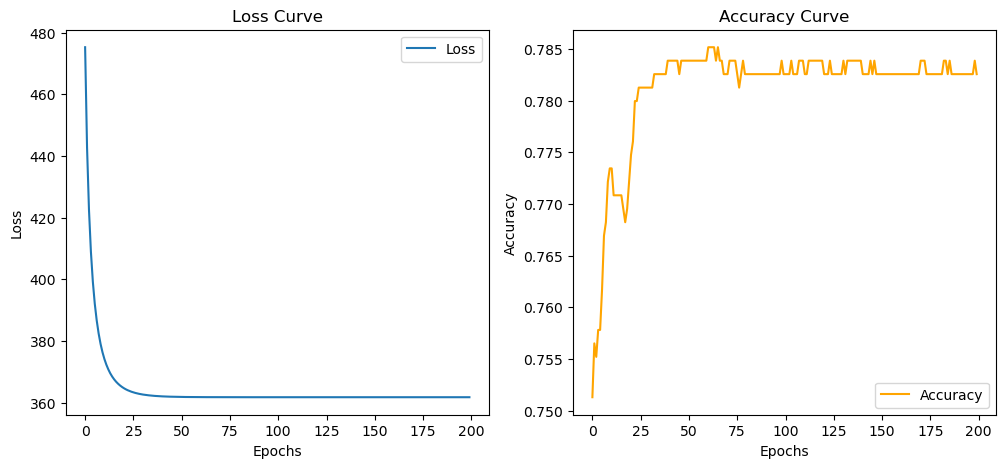

In [ ]:
# plot loss and accuracy curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epoch_loss, label='Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_acc, label='Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

In [160]:
def ADAM(l, grad_l, X, Y, Theta0, lr=1e-3, batch_size=32, epochs=200,  beta1=0.9, beta2=0.999, eps=1e-8):
    epoch_loss = []
    epoch_acc = []

    Theta = Theta0
    
    m = np.zeros_like(Theta)
    v = np.zeros_like(Theta)
    t = 0
    
    for epoch in range(epochs):
        N = len(X)
        shuffle_idx = np.random.permutation(N)

        for start in range(0, N, batch_size):
            batch_idx = shuffle_idx[start:start+batch_size]
            grad = grad_l(Theta, X[batch_idx], Y[batch_idx])

            t += 1
            m = beta1 * m + (1 - beta1) * grad
            v = beta2 * v + (1 - beta2) * (grad * grad)
            m_hat = m / (1 - beta1**t)
            v_hat = v / (1 - beta2**t)
            Theta -= lr * (m_hat / (np.sqrt(v_hat) + eps))


        epoch_loss.append(l(Theta, X, Y))
        epoch_acc.append(accuracy(Theta, X, Y))
            # Update the loss_val list

    return Theta, epoch, epoch_loss, epoch_acc

In [163]:
Theta0 = np.zeros(X.shape[1])
adam_Theta, adam_epoch, adam_epoch_loss, adam_epoch_acc = ADAM(l, grad_l, X, Y, Theta0=Theta0)

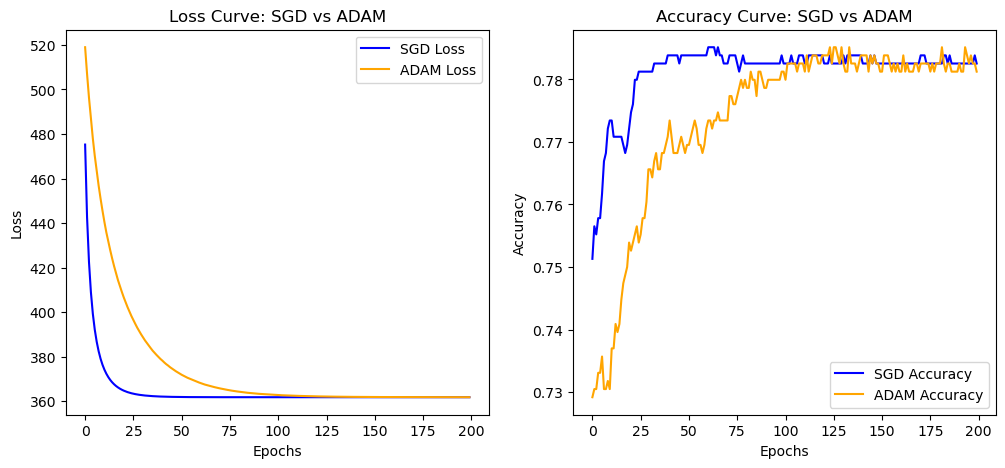

In [164]:
# Plot SDG vs ADAM loss curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epoch_loss, label='SGD Loss', color='blue')
plt.plot(adam_epoch_loss, label='ADAM Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve: SGD vs ADAM')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_acc, label='SGD Accuracy', color='blue')
plt.plot(adam_epoch_acc, label='ADAM Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve: SGD vs ADAM')
plt.legend()
plt.show()

In [165]:
Y_hat_SGD = (sigmoid(X @ Theta) >= 0.5).astype(int)
Y_hat_ADAM = (sigmoid(X @ adam_Theta) >= 0.5).astype(int)
SGD_report = classification_report(Y, Y_hat_SGD)
ADAM_report = classification_report(Y, Y_hat_ADAM)

In [166]:
display(pd.DataFrame([SGD_report, ADAM_report], index=['SGD', 'ADAM']))

,Accuracy,Precision,Recall,F1-Score,TP,TN,FP,FN,Confusion Matrix
SGD,0.783854,0.740566,0.585821,0.654167,157,445,55,111,"[[157, 55], [111, 445]]"
ADAM,0.781250,0.735849,0.582090,0.650000,156,444,56,112,"[[156, 56], [112, 444]]"


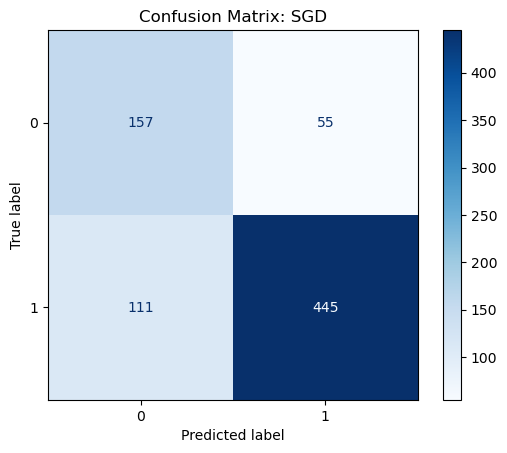

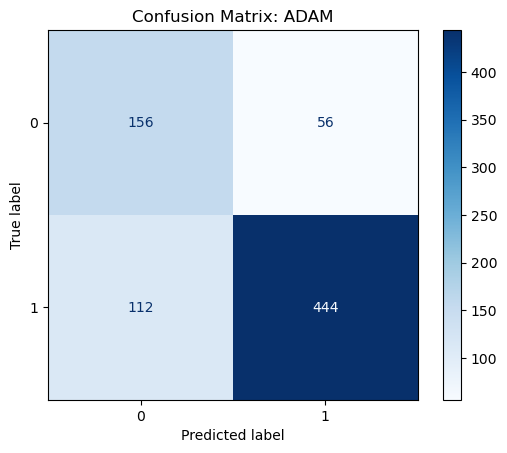

In [167]:
from sklearn.metrics import ConfusionMatrixDisplay

disp_SGD = ConfusionMatrixDisplay(confusion_matrix=SGD_report['Confusion Matrix'], display_labels=[0, 1])
disp_SGD.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: SGD')
plt.show()

disp_ADAM = ConfusionMatrixDisplay(confusion_matrix=ADAM_report['Confusion Matrix'], display_labels=[0, 1])
disp_ADAM.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: ADAM')
plt.show()

## Extension: Neural Network

In [175]:
import numpy as np

def sigmoid(z):
    return np.where(z >= 0,
             1/(1+np.exp(-z)),
             np.exp(z)/(1+np.exp(z))  # prevent overflow when z is large negative
            ) 

def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    g = np.zeros_like(z)
    g[z > 0] = 1.0
    return g

def bce_loss(y_hat, y, eps=1e-10):
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return -(y*np.log(y_hat) + (1-y)*np.log(1 - y_hat)).mean()

def train_mlp_adam(X, y, hidden=16, lr=1e-2, epochs=200, batch_size=32):
    N, d = X.shape

    W1 = np.random.normal(0, np.sqrt(2/d), size=(d, hidden))
    b1 = np.zeros((1, hidden))
    W2 = np.random.normal(0, np.sqrt(2/hidden), size=(hidden, 1))
    b2 = np.zeros((1, 1))

    losses, accs = [], []

    for _ in range(epochs):
        # Shuffle data
        idx = np.arange(len(X))
        np.random.shuffle(idx)

        X = X[idx, :]
        y = y[idx]

        for batch in range(0, N, batch_size):
            Xb, yb = X[batch:batch+batch_size], y[batch:batch+batch_size]

            # forward
            z1 = Xb @ W1 + b1
            a1 = relu(z1)
            z2 = a1 @ W2 + b2
            y_hat = sigmoid(z2)

            # backward
            delta2 = (y_hat - yb) / len(yb)
            dW2 = a1.T @ delta2
            db2 = delta2.sum(axis=0, keepdims=True)

            delta1 = (delta2 @ W2.T) * relu_grad(z1)
            dW1 = Xb.T @ delta1
            db1 = delta1.sum(axis=0, keepdims=True)

            # update
            W1 -= lr * dW1
            b1 -= lr * db1
            W2 -= lr * dW2
            b2 -= lr * db2

        # track
        z1 = X @ W1 + b1
        a1 = relu(z1)
        z2 = a1 @ W2 + b2
        yhat_full = sigmoid(z2)

        losses.append(bce_loss(yhat_full, y))
        preds = (yhat_full >= 0.5).astype(int)
        accs.append((preds == y).mean())

    return (W1, b1, W2, b2), np.array(losses), np.array(accs)

In [177]:
Y= Y.reshape(-1,1)

X.shape, Y.shape

((768, 9), (768, 1))

In [178]:
theta_nn_sgd, loss_nn_sgd, acc_nn_sgd = train_mlp_adam(
    X, Y,
    hidden=16,       
    lr=1e-3,
    epochs=200,
    batch_size=32,
)
print(f"Neural Network final accuracy: {acc_nn_sgd[-1]*100:.2f}%")

Neural Network final accuracy: 75.26%


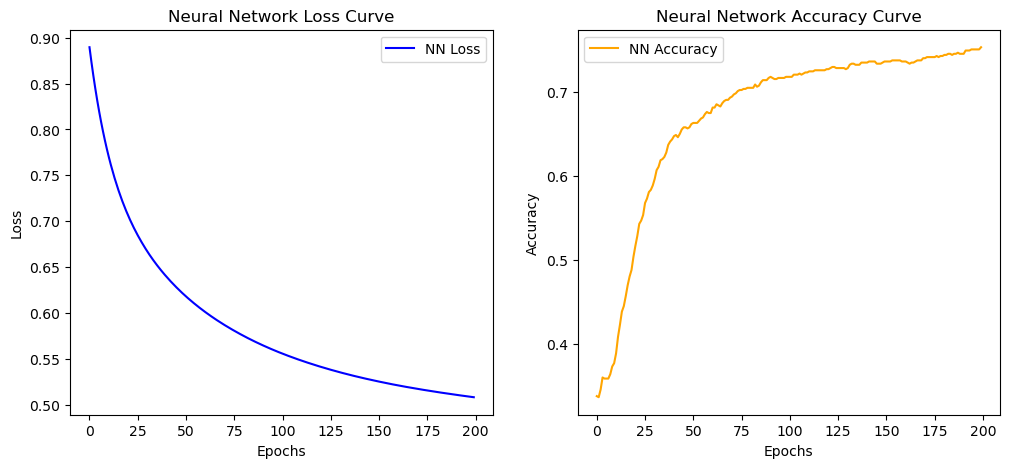

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_nn_sgd, label='NN Loss', color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Neural Network Loss Curve')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(acc_nn_sgd, label='NN Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Neural Network Accuracy Curve')
plt.legend()
plt.show()

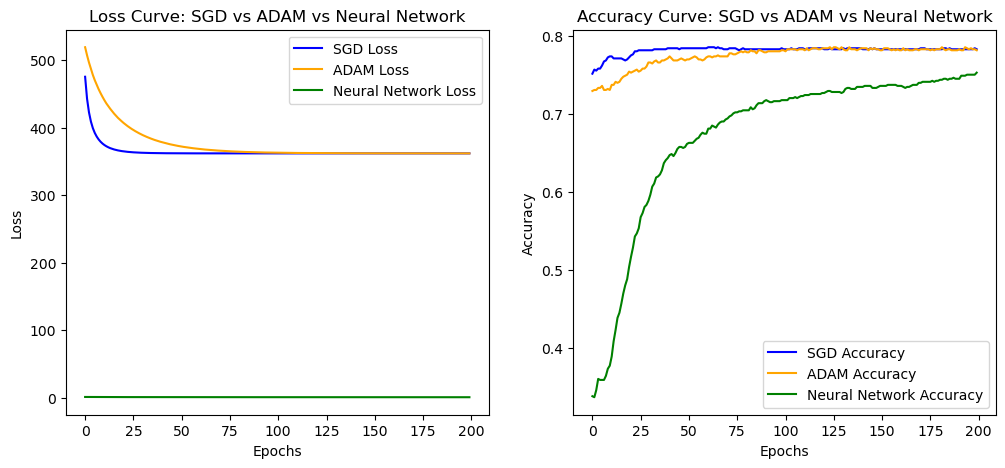

In [179]:
# Plot loss and accuracy curves for Adam Vs SGD VS Neural Network
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epoch_loss, label='SGD Loss', color='blue')
plt.plot(adam_epoch_loss, label='ADAM Loss', color='orange')
plt.plot(loss_nn_sgd, label='Neural Network Loss', color='green')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve: SGD vs ADAM vs Neural Network')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_acc, label='SGD Accuracy', color='blue')
plt.plot(adam_epoch_acc, label='ADAM Accuracy', color='orange')
plt.plot(acc_nn_sgd, label='Neural Network Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve: SGD vs ADAM vs Neural Network')
plt.legend()

plt.show()